Created by Sanish Bhochhibhoya (03/08/2025)

In [1]:
import sys, importlib
sys.path.insert(0, r'F:\V_Tech Semesters\MS Thesis\Jupyter_MS\2D_Model_Generator')

In [72]:
import geomodgen2d
import geomodgen2d.interfaces_creator2d as interface_creator
import geomodgen2d.discretized_interfaces2d as discretized_interfaces2d
from geomodgen2d.discretized_domain2d import DiscretizedDomain2D
import geomodgen2d.general_functions as f
import numpy as np
import geomodgen2d.lithological_domain2d as lithological_domain2d


In [133]:
boundary_dh = 0.25
surface_boundary2D = discretized_interfaces2d.SurfaceInterface2D(
    domain=domain2D, rng=np.random.default_rng(2), remesh_interp_method=remesh_interp_method)
surface_boundary2D.set_interfaces_matrix([[0.6], [0.2], [0], [1], [1.2], [0.5]])
surface_boundary2D=surface_boundary2D.remesh_interface(boundary_dh, boundary_dh)
surface_boundary2D.interfaces_matrix

array([[0.44],
       [0.36],
       [0.28],
       [0.2 ],
       [0.16],
       [0.12],
       [0.08],
       [0.04],
       [0.  ],
       [0.2 ],
       [0.4 ],
       [0.6 ],
       [0.8 ],
       [1.  ],
       [1.04],
       [1.08],
       [1.12],
       [1.16],
       [1.2 ],
       [1.06],
       [0.92],
       [0.78]])

In [132]:
# LithologicalDomain2D UnitTests
importlib.reload(lithological_domain2d)
setting = 4

remesh_interp_method = 'nearest'
boundary_dh = 1
surf_type = 'erode'
obs_dhx = 0.5
obs_dhz = 0.5


if setting == 1:
    to_npz = r'./test/data/lit_domain_test_coarse_nearest.npz'
elif setting == 2:
    remesh_interp_method = 'linear'
    surf_type = 'pile'
    to_npz = r'./test/data/lit_domain_test_coarse_linear.npz'
elif setting == 3:
    remesh_interp_method = 'nearest'
    boundary_dh = 0.25
    surf_type = 'erode'
    obs_dhx = 0.2
    obs_dhz = 0.1
    to_npz = r'./test/data/lit_domain_test_dense_linear.npz'
else:
    remesh_interp_method = 'linear'
    boundary_dh = 0.25
    surf_type = 'pile'
    obs_dhx = 0.2
    obs_dhz = 0.1
    to_npz = r'./test/data/lit_domain_test_dense_nearest.npz'

to_save = {}
gwt_depth = 1.8


In [131]:
domain2D = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=1, dz=1
)
boundary2D = discretized_interfaces2d.DiscretizedInterfaces2D(
    domain=domain2D, n_interfaces=3, rng=np.random.default_rng(2), remesh_interp_method=remesh_interp_method)

boundary = [[0.97, 3.39, 3.39],
            [0.97, 3.39, 3.39],
            [1.41, 3.5, 3.67],
            [1.85, 3.1, 3.95],
            [2.29, 2.7, 4.23],
            [2.73, 2.73, 4.51],
            [2.73, 2.73, 4.51]]

boundary2D.set_interfaces_matrix(boundary)

domain2D = domain2D.remesh(1.25)
surface_boundary2D = discretized_interfaces2d.SurfaceInterface2D(
    domain=domain2D, rng=np.random.default_rng(2), remesh_interp_method=remesh_interp_method)
surface_boundary2D.set_interfaces_matrix([[0.6], [0.2], [0], [1], [1.2], [0.5]])

if boundary_dh is not None:
    boundary2D=boundary2D.remesh_interface(boundary_dh, boundary_dh)
    surface_boundary2D=surface_boundary2D.remesh_interface(boundary_dh, boundary_dh)
# surface_boundary2D = None
print(surface_boundary2D.interfaces_matrix)

to_save['boundary2D_matrix'] = boundary2D.interfaces_matrix
# to_save['surfboundary2D_matrix'] = surface_boundary2D.interfaces_matrix

config = lithological_domain2d.GlobalSoilInterfaceConfig
config.set_soil_interface(boundary2D, surface_boundary2D, surf_type)
print(surface_boundary2D.interfaces_matrix)

obs2D1 = geomodgen2d.obstruction_2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('C', 0), snap_to_dl=False)  #Should be same as above
obs2D1.circular_2d(2, 1)

obs2D2 = geomodgen2d.obstruction_2d.Obstruction2D(dl=0.5, ref_xz_symbolic=('0', 0), snap_to_dl=False)  #Should be same as above
obs2D2.rectangle_2d(3, 2, 2)


[[0.44]
 [0.36]
 [0.28]
 [0.2 ]
 [0.16]
 [0.12]
 [0.08]
 [0.04]
 [0.  ]
 [0.2 ]
 [0.4 ]
 [0.6 ]
 [0.8 ]
 [1.  ]
 [1.04]
 [1.08]
 [1.12]
 [1.16]
 [1.2 ]
 [1.06]
 [0.92]
 [0.78]]
[[0.44]
 [0.36]
 [0.28]
 [0.2 ]
 [0.16]
 [0.12]
 [0.08]
 [0.04]
 [0.  ]
 [0.2 ]
 [0.4 ]
 [0.6 ]
 [0.8 ]
 [1.  ]
 [1.04]
 [1.08]
 [1.12]
 [1.16]
 [1.2 ]
 [1.06]
 [0.92]
 [0.78]]


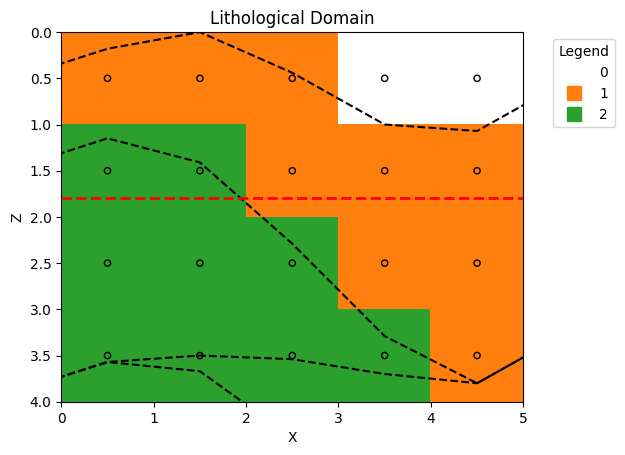

In [116]:
name = 'lit_domain1'
lit = lithological_domain2d.LithologicalDomain2D(gwt_depth, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
# boundary.io.print()

to_save['lit_domain1_matrix'] = lit.lithological_matrix

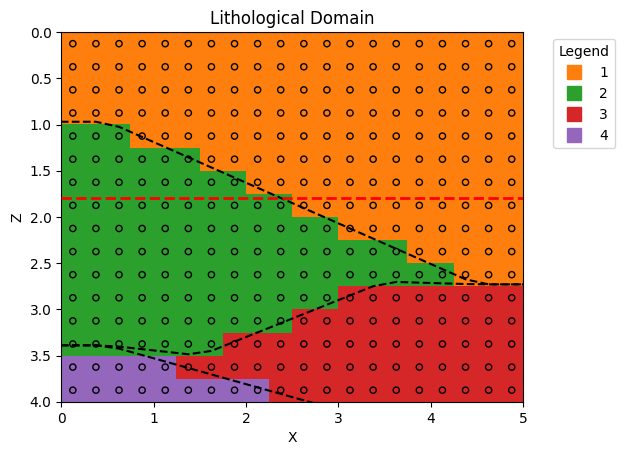

In [123]:
name = 'lit_domain1'
lit = lithological_domain2d.LithologicalDomain2D(gwt_depth, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
# boundary.io.print()

to_save['lit_domain1_matrix'] = lit.lithological_matrix

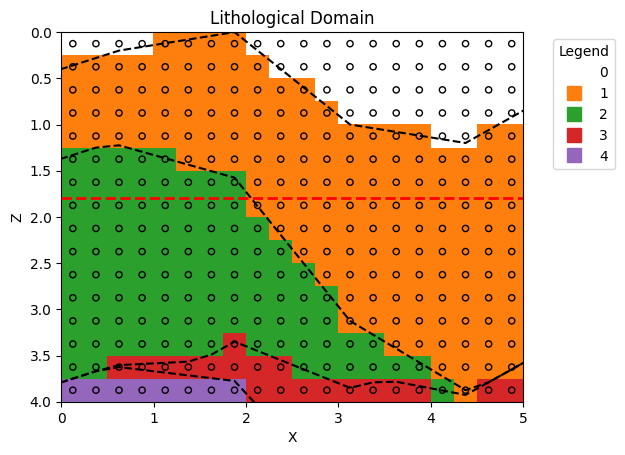

In [127]:
name = 'lit_domain1'
lit = lithological_domain2d.LithologicalDomain2D(gwt_depth, name)
# lit.remeshing_layered_matrix(span_x, span_z, del_x_final, del_z_final)
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
# boundary.io.print()

to_save['lit_domain1_matrix'] = lit.lithological_matrix

In [128]:
print(setting, boundary2D.interfaces_matrix, surface_boundary2D.interfaces_matrix, config.get_interface_instance().interfaces_matrix)

4 [[0.97    3.39    3.39   ]
 [0.97    3.39    3.39   ]
 [0.97    3.39    3.39   ]
 [1.025   3.40375 3.425  ]
 [1.135   3.43125 3.495  ]
 [1.245   3.45875 3.565  ]
 [1.355   3.48625 3.635  ]
 [1.465   3.45    3.705  ]
 [1.575   3.35    3.775  ]
 [1.685   3.25    3.845  ]
 [1.795   3.15    3.915  ]
 [1.905   3.05    3.985  ]
 [2.015   2.95    4.055  ]
 [2.125   2.85    4.125  ]
 [2.235   2.75    4.195  ]
 [2.345   2.70375 4.265  ]
 [2.455   2.71125 4.335  ]
 [2.565   2.71875 4.405  ]
 [2.675   2.72625 4.475  ]
 [2.73    2.73    4.51   ]
 [2.73    2.73    4.51   ]
 [2.73    2.73    4.51   ]] [[0.44]
 [0.36]
 [0.28]
 [0.2 ]
 [0.16]
 [0.12]
 [0.08]
 [0.04]
 [0.  ]
 [0.2 ]
 [0.4 ]
 [0.6 ]
 [0.8 ]
 [1.  ]
 [1.04]
 [1.08]
 [1.12]
 [1.16]
 [1.2 ]
 [1.06]
 [0.92]
 [0.78]] [[0.44    1.41    3.83    3.83   ]
 [0.36    1.33    3.75    3.75   ]
 [0.28    1.25    3.67    3.67   ]
 [0.2     1.225   3.60375 3.625  ]
 [0.16    1.295   3.59125 3.655  ]
 [0.12    1.365   3.57875 3.685  ]
 [0.08    1.435 

In [124]:
boundary2D.interfaces_matrix

array([[0.97   , 3.39   , 3.39   ],
       [0.97   , 3.39   , 3.39   ],
       [0.97   , 3.39   , 3.39   ],
       [1.025  , 3.40375, 3.425  ],
       [1.135  , 3.43125, 3.495  ],
       [1.245  , 3.45875, 3.565  ],
       [1.355  , 3.48625, 3.635  ],
       [1.465  , 3.45   , 3.705  ],
       [1.575  , 3.35   , 3.775  ],
       [1.685  , 3.25   , 3.845  ],
       [1.795  , 3.15   , 3.915  ],
       [1.905  , 3.05   , 3.985  ],
       [2.015  , 2.95   , 4.055  ],
       [2.125  , 2.85   , 4.125  ],
       [2.235  , 2.75   , 4.195  ],
       [2.345  , 2.70375, 4.265  ],
       [2.455  , 2.71125, 4.335  ],
       [2.565  , 2.71875, 4.405  ],
       [2.675  , 2.72625, 4.475  ],
       [2.73   , 2.73   , 4.51   ],
       [2.73   , 2.73   , 4.51   ],
       [2.73   , 2.73   , 4.51   ]])

In [120]:
print(setting, boundary2D.interfaces_matrix, surface_boundary2D.interfaces_matrix, config.get_interface_instance().interfaces_matrix)

2 [[0.97 3.39 3.39]
 [0.97 3.39 3.39]
 [1.41 3.5  3.67]
 [1.85 3.1  3.95]
 [2.29 2.7  4.23]
 [2.73 2.73 4.51]
 [2.73 2.73 4.51]] [[0.56]
 [0.24]
 [0.06]
 [0.5 ]
 [1.06]
 [1.13]
 [0.57]] [[0.5  1.47 3.89 3.89]
 [0.18 1.15 3.57 3.57]
 [0.   1.41 3.5  3.67]
 [0.44 2.29 3.54 4.39]
 [1.   3.29 3.7  5.23]
 [1.07 3.8  3.8  5.58]
 [0.51 3.24 3.24 5.02]]


In [112]:
print(setting, boundary2D.interfaces_matrix)

2 [[0.97 3.39 3.39]
 [0.97 3.39 3.39]
 [1.41 3.5  3.67]
 [1.85 3.1  3.95]
 [2.29 2.7  4.23]
 [2.73 2.73 4.51]
 [2.73 2.73 4.51]]


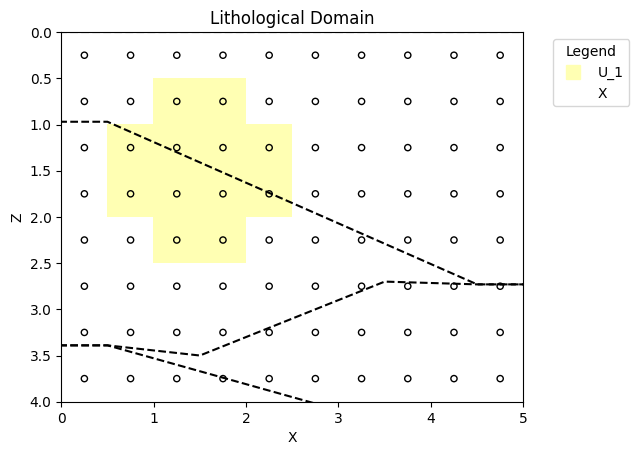

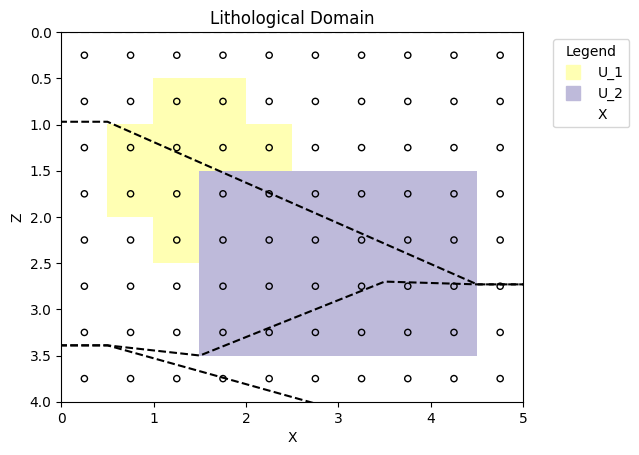

In [113]:
domain2D_obs = geomodgen2d.discretized_domain2d.DiscretizedDomain2D(
    span_x=5, span_z=4, dx=obs_dhx, dz=obs_dhz
)

obs1_ref_point = [1.25, .74] #edge cases... minus .01 to the left 
obs2_ref_point = [1.38,1.44]

obs_lit = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
# obs_lit.add_obstruction2D(obs2D1, [1.4,1.7], 'U')
obs_lit.add_obstruction2D(obs2D1, obs1_ref_point, 'U')
# obs2D2.plot(discrete_point_size = 20)
obs_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

obs_lit.add_obstruction2D(obs2D2, obs2_ref_point, 'U')
obs_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

to_save['obs_lit_matrix'] = obs_lit.lithological_matrix

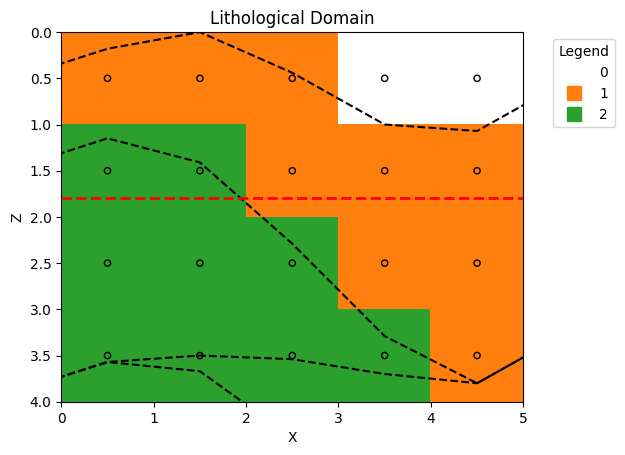

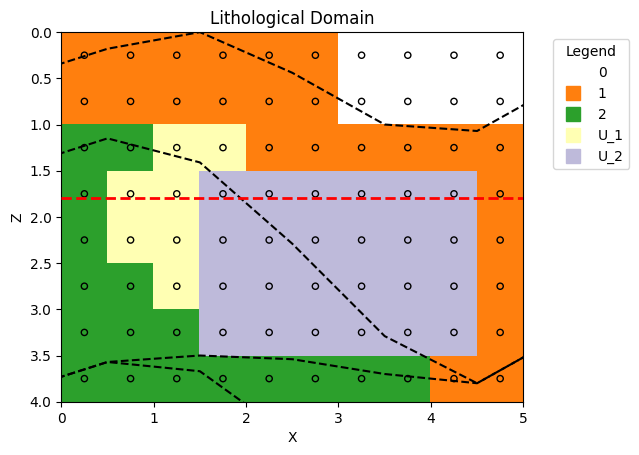

In [67]:
merged_lit = lit.return_merged_lithological_domain([obs_lit])
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
merged_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

to_save['merged_lit_matrix'] = merged_lit.lithological_matrix

<Axes: title={'center': 'Lithological Domain'}, xlabel='X', ylabel='Z'>

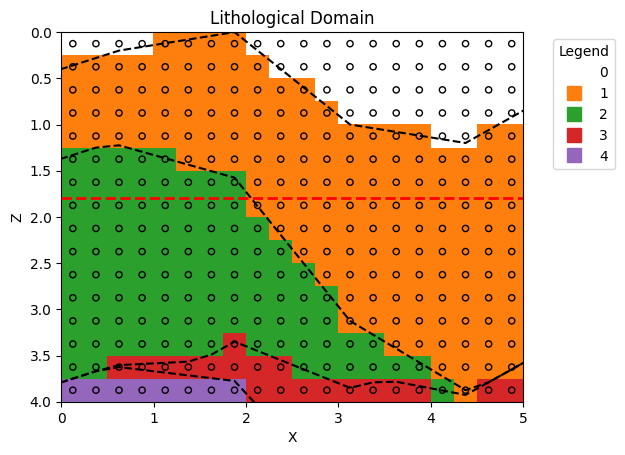

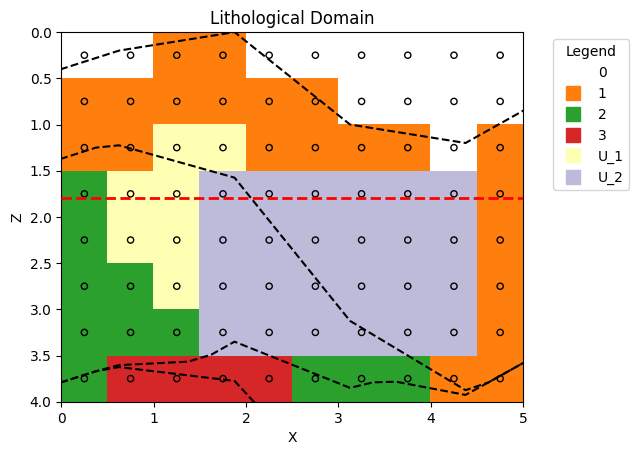

In [71]:
### TO THINK: WHY INTERFACE PATTERN CHANGED ON REMESHING..
### I THINK THIS IS NOT AN ISSUE IF WE DO DOMAIN DISCRETIZATION ONLY NO INTERFACE DISCRETIZATION. BUT DO CHECK.

lit = lithological_domain2d.LithologicalDomain2D(gwt_depth, name)

obs_lit1 = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
obs_lit1.add_obstruction2D(obs2D1, obs1_ref_point, 'U')

obs_lit2 = lithological_domain2d.LithologicalDomain2DFromObstruction2D(domain2D_obs, 'obst')
obs_lit2.add_obstruction2D(obs2D2, obs2_ref_point, 'U')

merged_lit = lit.return_merged_lithological_domain([obs_lit1, obs_lit2])
lit.plot2d(discrete_point_size = 20, plot_boundary=True)
merged_lit.plot2d(discrete_point_size = 20, plot_boundary=True)

In [22]:
np.savez_compressed(to_npz, **to_save)

In [23]:
data = np.load(to_npz)
loaded_dict = {key: data[key] for key in data.files}

for key in to_save.keys():
    print(key)
    a = to_save[key]
    b = loaded_dict[key]

    # string or object arrays → direct equality
    if a.dtype.kind in {"U", "S", "O"}:
        assert np.array_equal(a, b)
    else:
        assert np.isclose(a,b).all()

boundary2D_matrix
surfboundary2D_matrix
lit_domain1_matrix
obs_lit_matrix
merged_lit_matrix
